In [1]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

In [1]:
from matplotlib import pyplot as plt 

In [9]:
import math 
# Fibonacci-based magnitudes
fib = torch.tensor([1., 1., 2.])
fib = fib / fib.norm()   # normalize for stability

# fan_in = 3 * 3
fan_in = 9
scale = math.sqrt(2 / fan_in)  # He-style scaling

# Initialize kernel
k = torch.zeros(3, 3)

# Left column (positive)
k[:, 0] = fib

# Middle column (zero)
k[:, 1] = 0.0

# Right column (negative)
k[:, 2] = -fib

# Apply variance scaling
k *= scale

k


tensor([[ 0.1925,  0.0000, -0.1925],
        [ 0.1925,  0.0000, -0.1925],
        [ 0.3849,  0.0000, -0.3849]])

In [10]:
(img[7:10,7:10] * k ).sum()

tensor(-0.5668)

In [11]:
# let image size 5x5
torch.rand(5,5)

tensor([[0.2055, 0.1305, 0.2062, 0.0914, 0.9022],
        [0.7255, 0.1950, 0.5980, 0.3694, 0.1644],
        [0.5925, 0.7632, 0.0299, 0.6045, 0.3993],
        [0.9935, 0.0862, 0.5635, 0.3107, 0.1221],
        [0.9888, 0.0641, 0.3198, 0.1646, 0.8727]])

In [12]:
# when we apply filter of 3x3 with stride 1 image size reduced by 2 rows and 2 columns

In [13]:
r , c = img.shape
r,c

(28, 28)

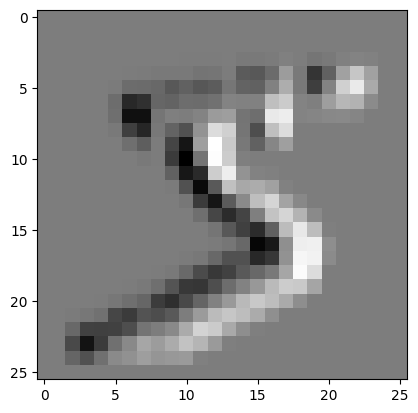

In [18]:
def conv2d_single_channel(image, kernel, stride:int() = 1 ):
    """
    image  : torch.Tensor of shape (H, W) or (1, H, W)
    kernel : torch.Tensor of shape (kH, kW)
    stride : int
    return : torch.Tensor of shape (H_out, W_out)
    """
# H stands for height and W stands for width 
    # ensure image is (H, W)
    if image.dim == 3 :
        image.squeeze(0)

    H , W = image.shape
    kH , kW = kernel.shape
    H_out = (H - kH) // stride + 1 
    W_out = (W - kW) // stride + 1 
    output = torch.zeros((H_out,W_out))

    for h in range(H_out):
        for w in range(W_out):
            h_start = h * stride
            w_start = w * stride
            
            patch = image[h_start:h_start+kH, w_start:w_start+kW]
            output[h,w] = torch.sum(patch * kernel)

    return output    
plt.imshow(conv2d_single_channel(img , k ), cmap="gray")

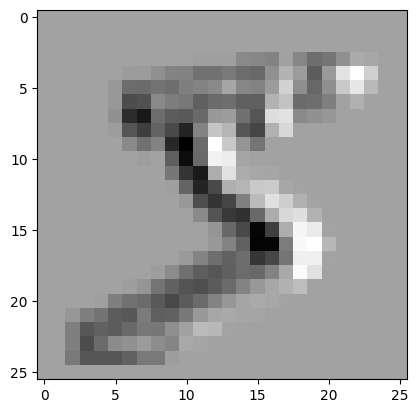

In [19]:
# # kernal/ filter 
k = torch.rand(3,3)* (2/9)**0.5
k[:,1] = 0 
k[:,2] *= -1 
k
plt.imshow(conv2d_single_channel(img,k),cmap="gray")

In [20]:
def conv2d_multi_filter(image, kernels, stride=1):
    """
    image   : torch.Tensor of shape (H, W) or (1, H, W)
    kernels : torch.Tensor of shape (F, kH, kW)
    stride  : int

    return  : torch.Tensor of shape (F, H_out, W_out)
    """

    # ensure image is (H, W)
    if image.dim() == 3:
        image = image.squeeze(0)

    H, W = image.shape
    F, kH, kW = kernels.shape

    H_out = (H - kH) // stride + 1
    W_out = (W - kW) // stride + 1

    output = torch.zeros((F, H_out, W_out))

    for f in range(F):               # loop over filters
        kernel = kernels[f]

        for i in range(H_out):
            for j in range(W_out):
                h_start = i * stride
                w_start = j * stride

                patch = image[h_start:h_start + kH,
                              w_start:w_start + kW]

                output[f, i, j] = torch.sum(patch * kernel)

    return output


In [50]:
kernels = torch.randn(8, 3, 3)

out = conv2d_multi_filter(img, kernels)

print(out.shape)


torch.Size([8, 24, 24])


In [22]:
out[0].shape

torch.Size([26, 26])

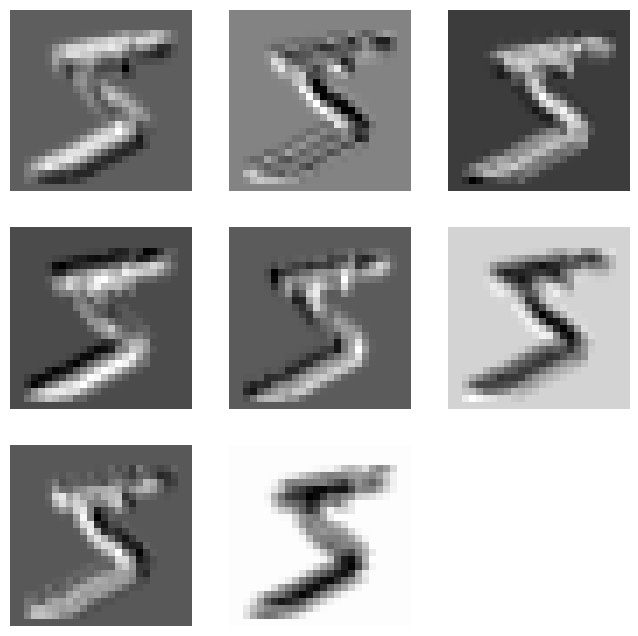

In [28]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3 ,3
for i in range(1, cols * rows  ):
    img = out[i-1]
    figure.add_subplot(rows, cols, i)
    plt.axis("off")
    plt.imshow(img, cmap="gray")
plt.show()

In [29]:
output = conv2d_single_channel(img,k)
def relu_forward(x):
    """
    x : torch.Tensor (any shape)
    return:
        out : ReLU activated tensor
        cache : x (stored for backward)
    """
    out = torch.clamp(x, min=0)
    cache = x
    return out, cache


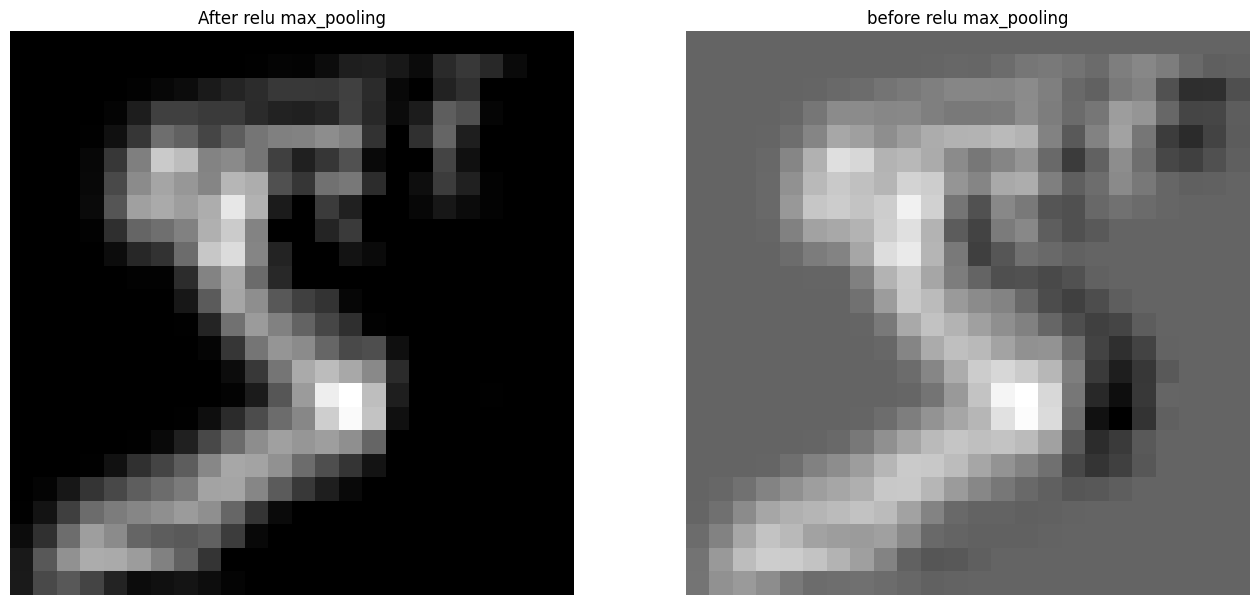

In [32]:
out ,cache = relu_forward(output)
figure = plt.figure(figsize=(16, 8))
cols, rows = 2 ,1
figure.add_subplot(rows, cols, 1)
plt.axis("off")
plt.imshow(out, cmap="gray")
plt.title("After relu max_pooling")
figure.add_subplot(rows, cols, 2)
plt.axis("off")
plt.imshow(cache, cmap="gray")
plt.title("before relu max_pooling")
plt.show()

In [51]:
def maxpool2d_forward(x, pool_size=2, stride=2):
    C, H, W = x.shape
    H_out = H // pool_size
    W_out = W // pool_size

    out = torch.zeros((C, H_out, W_out))
    mask = {}

    for c in range(C):
        for i in range(0, H, stride):
            for j in range(0, W, stride):
                window = x[c, i:i+pool_size, j:j+pool_size]
                max_val = window.max()
                out[c, i//stride, j//stride] = max_val

                # store index
                idx = torch.argmax(window)
                di, dj = idx // pool_size, idx % pool_size
                mask[(c, i//stride, j//stride)] = (i+di, j+dj)

    return out, mask
out , mask = maxpool2d_forward(out)

Text(0.5, 1.0, 'After relu max_pooling')

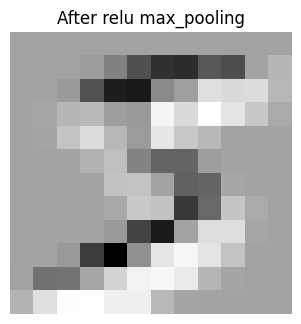

In [56]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 2 ,1
figure.add_subplot(rows, cols, 1)
plt.axis("off")
plt.imshow(out[0], cmap="gray")
plt.title("After relu max_pooling")
